In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

In [2]:
TRAIN_PATH_1 = "segment_alerts_all_airports_train.csv"   # ex: 2016-2022
TRAIN_PATH_2 = "dataset_set.csv"                         # ex: 2023-2025, à adapter si besoin

df1 = pd.read_csv(TRAIN_PATH_1)
df2 = pd.read_csv(TRAIN_PATH_2)

df = pd.concat([df1, df2], ignore_index=True)

df["date"] = pd.to_datetime(df["date"], utc=True)

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df["icloud"] = df["icloud"].astype(bool)

print("Shape total :", df.shape)
print(df.head())
print("\nPériode :", df["date"].min(), "->", df["date"].max())
print("\nRépartition par année :")
print(df["date"].dt.year.value_counts().sort_index())

Shape total : (691016, 13)
   lightning_id  lightning_airport_id                      date     lon  \
0             1                     1 2016-01-02 14:53:36+00:00  9.0559   
1             2                     2 2016-01-02 14:53:36+00:00  9.0236   
2             3                     3 2016-01-02 21:22:53+00:00  8.8585   
3             4                     4 2016-01-02 21:22:53+00:00  8.8517   
4             5                     5 2016-01-02 21:24:46+00:00  8.8728   

       lat  amplitude  maxis  icloud       dist    azimuth  airport  \
0  42.0826      -9.90    0.3   False  27.360653  57.852343  Ajaccio   
1  42.0953      -3.33    0.2    True  26.383167  52.117828  Ajaccio   
2  42.0456     -18.68    0.4    True  14.313391  24.500543  Ajaccio   
3  42.0517      -7.51    0.2   False  14.794117  20.854458  Ajaccio   
4  42.0494      -6.01    0.2   False  15.124224  29.058471  Ajaccio   

   airport_alert_id is_last_lightning_cloud_ground  
0               NaN                       

In [22]:
# type d'éclair
df["is_cg"] = (~df["icloud"]).astype("int8")   # nuage-sol
df["is_ic"] = df["icloud"].astype("int8")      # intra-nuage

# zones de distance
df["is_0_3"] = (df["dist"] < 3).astype("int8")
df["is_3_10"] = ((df["dist"] >= 3) & (df["dist"] < 10)).astype("int8")
df["is_10_20"] = ((df["dist"] >= 10) & (df["dist"] < 20)).astype("int8")
df["is_20_30"] = ((df["dist"] >= 20) & (df["dist"] < 30)).astype("int8")

# utile pour stats d'intensité
df["amp_abs"] = df["amplitude"].abs()

print(df[[
    "airport", "date", "dist", "icloud",
    "is_cg", "is_ic", "is_0_3", "is_3_10", "is_10_20", "is_20_30", "amp_abs"
]].head())

   airport                      date       dist  icloud  is_cg  is_ic  is_0_3  \
0  Ajaccio 2016-01-02 14:53:36+00:00  27.360653   False      1      0       0   
1  Ajaccio 2016-01-02 14:53:36+00:00  26.383167    True      0      1       0   
2  Ajaccio 2016-01-02 21:22:53+00:00  14.313391    True      0      1       0   
3  Ajaccio 2016-01-02 21:22:53+00:00  14.794117   False      1      0       0   
4  Ajaccio 2016-01-02 21:24:46+00:00  15.124224   False      1      0       0   

   is_3_10  is_10_20  is_20_30  amp_abs  
0        0         0         1     9.90  
1        0         0         1     3.33  
2        0         1         0    18.68  
3        0         1         0     7.51  
4        0         1         0     6.01  


In [23]:
base = (
    df.groupby(["airport", "date"], as_index=False)
      .agg(
          n_total=("lightning_id", "size"),
          n_cg=("is_cg", "sum"),
          n_ic=("is_ic", "sum"),

          n_0_3=("is_0_3", "sum"),
          n_3_10=("is_3_10", "sum"),
          n_10_20=("is_10_20", "sum"),
          n_20_30=("is_20_30", "sum"),

          dist_min=("dist", "min"),
          dist_mean=("dist", "mean"),
          dist_max=("dist", "max"),

          amp_abs_mean=("amp_abs", "mean"),
          amp_abs_max=("amp_abs", "max"),
          maxis_mean=("maxis", "mean"),
          azimuth_mean=("azimuth", "mean"),
      )
      .sort_values(["airport", "date"])
      .reset_index(drop=True)
)

print("Shape base :", base.shape)
print(base.head(10))

Shape base : (568380, 16)
   airport                      date  n_total  n_cg  n_ic  n_0_3  n_3_10  \
0  Ajaccio 2016-01-02 14:53:36+00:00        2     1     1      0       0   
1  Ajaccio 2016-01-02 21:22:53+00:00        2     1     1      0       0   
2  Ajaccio 2016-01-02 21:24:46+00:00        1     1     0      0       0   
3  Ajaccio 2016-01-02 21:25:59+00:00        1     1     0      0       0   
4  Ajaccio 2016-01-02 21:27:04+00:00        1     1     0      0       0   
5  Ajaccio 2016-01-02 21:28:54+00:00        2     1     1      0       0   
6  Ajaccio 2016-01-02 21:32:23+00:00        1     0     1      0       0   
7  Ajaccio 2016-01-02 21:36:35+00:00        2     0     2      0       0   
8  Ajaccio 2016-01-02 21:43:06+00:00        1     0     1      0       0   
9  Ajaccio 2016-01-02 21:53:17+00:00        1     1     0      0       0   

   n_10_20  n_20_30   dist_min  dist_mean   dist_max  amp_abs_mean  \
0        0        2  26.383167  26.871910  27.360653         6.615 

In [24]:
base["hour"] = base["date"].dt.hour
base["month"] = base["date"].dt.month
base["dayofyear"] = base["date"].dt.dayofyear
base["weekday"] = base["date"].dt.weekday

base["hour_sin"] = np.sin(2 * np.pi * base["hour"] / 24)
base["hour_cos"] = np.cos(2 * np.pi * base["hour"] / 24)

base["month_sin"] = np.sin(2 * np.pi * base["month"] / 12)
base["month_cos"] = np.cos(2 * np.pi * base["month"] / 12)

print(base[[
    "airport", "date", "hour", "month", "dayofyear", "weekday",
    "hour_sin", "hour_cos", "month_sin", "month_cos"
]].head())

   airport                      date  hour  month  dayofyear  weekday  \
0  Ajaccio 2016-01-02 14:53:36+00:00    14      1          2        5   
1  Ajaccio 2016-01-02 21:22:53+00:00    21      1          2        5   
2  Ajaccio 2016-01-02 21:24:46+00:00    21      1          2        5   
3  Ajaccio 2016-01-02 21:25:59+00:00    21      1          2        5   
4  Ajaccio 2016-01-02 21:27:04+00:00    21      1          2        5   

   hour_sin  hour_cos  month_sin  month_cos  
0 -0.500000 -0.866025        0.5   0.866025  
1 -0.707107  0.707107        0.5   0.866025  
2 -0.707107  0.707107        0.5   0.866025  
3 -0.707107  0.707107        0.5   0.866025  
4 -0.707107  0.707107        0.5   0.866025  


In [25]:
labeled = df[df["airport_alert_id"].notna()].copy()

target_rows = []

for (airport, alert_id), g in labeled.groupby(["airport", "airport_alert_id"]):
    g = g.sort_values("date").copy()

    times = g[["date"]].drop_duplicates().sort_values("date").copy()
    t = times["date"].to_numpy()

    dangerous_times_3 = np.array(sorted(g.loc[g["dist"] < 3, "date"].unique()))
    dangerous_times_20 = np.array(sorted(g.loc[g["dist"] < 20, "date"].unique()))

    idx3 = np.searchsorted(dangerous_times_3, t, side="right")
    idx20 = np.searchsorted(dangerous_times_20, t, side="right")

    times["safe_to_end_now_3km"] = (idx3 == len(dangerous_times_3)).astype("int8")
    times["safe_to_end_now_20km"] = (idx20 == len(dangerous_times_20)).astype("int8")

    times["airport"] = airport
    times["airport_alert_id"] = alert_id
    target_rows.append(times)

target_df = pd.concat(target_rows, ignore_index=True)

print("Shape target_df :", target_df.shape)
print("\nRépartition 3km :")
print(target_df["safe_to_end_now_3km"].value_counts(normalize=True))

print("\nRépartition 20km :")
print(target_df["safe_to_end_now_20km"].value_counts(normalize=True))

print(target_df.head(10))

Shape target_df : (67051, 5)

Répartition 3km :
safe_to_end_now_3km
1    0.51337
0    0.48663
Name: proportion, dtype: float64

Répartition 20km :
safe_to_end_now_20km
0    0.952215
1    0.047785
Name: proportion, dtype: float64
                       date  safe_to_end_now_3km  safe_to_end_now_20km  \
0 2016-01-02 21:22:53+00:00                    1                     0   
1 2016-01-02 21:24:46+00:00                    1                     0   
2 2016-01-02 21:25:59+00:00                    1                     0   
3 2016-01-02 21:27:04+00:00                    1                     0   
4 2016-01-02 21:28:54+00:00                    1                     1   
5 2016-01-12 06:37:45+00:00                    1                     1   
6 2016-01-12 07:25:37+00:00                    1                     1   
7 2016-02-07 14:05:14+00:00                    1                     1   
8 2016-02-07 14:35:39+00:00                    1                     1   
9 2016-02-25 14:10:03+00:00    

In [26]:
parts = []

for airport, g in base.groupby("airport"):
    g = g.sort_values("date").copy()

    g["delta_prev_min"] = g["date"].diff().dt.total_seconds().div(60).fillna(9999)

    last_0_3_date = g["date"].where(g["n_0_3"] > 0).ffill().shift()
    g["since_last_0_3_min"] = (
        (g["date"] - last_0_3_date).dt.total_seconds().div(60).fillna(9999)
    )

    last_3_10_date = g["date"].where(g["n_3_10"] > 0).ffill().shift()
    g["since_last_3_10_min"] = (
        (g["date"] - last_3_10_date).dt.total_seconds().div(60).fillna(9999)
    )

    last_10_20_date = g["date"].where(g["n_10_20"] > 0).ffill().shift()
    g["since_last_10_20_min"] = (
        (g["date"] - last_10_20_date).dt.total_seconds().div(60).fillna(9999)
    )

    last_20_30_date = g["date"].where(g["n_20_30"] > 0).ffill().shift()
    g["since_last_20_30_min"] = (
        (g["date"] - last_20_30_date).dt.total_seconds().div(60).fillna(9999)
    )

    last_cg_date = g["date"].where(g["n_cg"] > 0).ffill().shift()
    g["since_last_cg_min"] = (
        (g["date"] - last_cg_date).dt.total_seconds().div(60).fillna(9999)
    )

    parts.append(g)

base_time = pd.concat(parts, ignore_index=True)

print(base_time.shape)
print(base_time.head(10))

(568380, 30)
   airport                      date  n_total  n_cg  n_ic  n_0_3  n_3_10  \
0  Ajaccio 2016-01-02 14:53:36+00:00        2     1     1      0       0   
1  Ajaccio 2016-01-02 21:22:53+00:00        2     1     1      0       0   
2  Ajaccio 2016-01-02 21:24:46+00:00        1     1     0      0       0   
3  Ajaccio 2016-01-02 21:25:59+00:00        1     1     0      0       0   
4  Ajaccio 2016-01-02 21:27:04+00:00        1     1     0      0       0   
5  Ajaccio 2016-01-02 21:28:54+00:00        2     1     1      0       0   
6  Ajaccio 2016-01-02 21:32:23+00:00        1     0     1      0       0   
7  Ajaccio 2016-01-02 21:36:35+00:00        2     0     2      0       0   
8  Ajaccio 2016-01-02 21:43:06+00:00        1     0     1      0       0   
9  Ajaccio 2016-01-02 21:53:17+00:00        1     1     0      0       0   

   n_10_20  n_20_30   dist_min  ...  hour_sin  hour_cos  month_sin  month_cos  \
0        0        2  26.383167  ... -0.500000 -0.866025        0.5   

In [27]:
windows = ["5min", "10min", "20min", "30min", "60min"]

count_cols = [
    "n_total", "n_cg", "n_ic",
    "n_0_3", "n_3_10", "n_10_20", "n_20_30"
]

mean_cols = [
    "dist_min", "dist_mean", "dist_max",
    "amp_abs_mean", "amp_abs_max", "maxis_mean", "azimuth_mean"
]

parts = []

for airport, g in base_time.groupby("airport"):
    g = g.sort_values("date").copy().set_index("date")
    out = g.copy()

    for w in windows:
        roll_sum = g[count_cols].rolling(w, closed="both").sum()
        roll_sum.columns = [f"{c}__sum_{w}" for c in roll_sum.columns]

        roll_mean = g[mean_cols].rolling(w, closed="both").mean()
        roll_mean.columns = [f"{c}__mean_{w}" for c in roll_mean.columns]

        out = pd.concat([out, roll_sum, roll_mean], axis=1)

    out = out.reset_index()
    parts.append(out)

features_all = pd.concat(parts, ignore_index=True)

print("Shape features_all :", features_all.shape)
print(features_all.head(10))

Shape features_all : (568380, 100)
                       date  airport  n_total  n_cg  n_ic  n_0_3  n_3_10  \
0 2016-01-02 14:53:36+00:00  Ajaccio        2     1     1      0       0   
1 2016-01-02 21:22:53+00:00  Ajaccio        2     1     1      0       0   
2 2016-01-02 21:24:46+00:00  Ajaccio        1     1     0      0       0   
3 2016-01-02 21:25:59+00:00  Ajaccio        1     1     0      0       0   
4 2016-01-02 21:27:04+00:00  Ajaccio        1     1     0      0       0   
5 2016-01-02 21:28:54+00:00  Ajaccio        2     1     1      0       0   
6 2016-01-02 21:32:23+00:00  Ajaccio        1     0     1      0       0   
7 2016-01-02 21:36:35+00:00  Ajaccio        2     0     2      0       0   
8 2016-01-02 21:43:06+00:00  Ajaccio        1     0     1      0       0   
9 2016-01-02 21:53:17+00:00  Ajaccio        1     1     0      0       0   

   n_10_20  n_20_30   dist_min  ...  n_3_10__sum_60min  n_10_20__sum_60min  \
0        0        2  26.383167  ...               

In [28]:
eps = 1e-6

features_all["trend_total_5_vs_10"] = (
    features_all["n_total__sum_5min"] / (features_all["n_total__sum_10min"] + eps)
)

features_all["trend_0_3_5_vs_10"] = (
    features_all["n_0_3__sum_5min"] / (features_all["n_0_3__sum_10min"] + eps)
)

features_all["trend_10_20_5_vs_10"] = (
    features_all["n_10_20__sum_5min"] / (features_all["n_10_20__sum_10min"] + eps)
)

features_all["trend_20_30_5_vs_10"] = (
    features_all["n_20_30__sum_5min"] / (features_all["n_20_30__sum_10min"] + eps)
)

features_all["far_vs_near_10min"] = (
    (features_all["n_20_30__sum_10min"] + 1) /
    (features_all["n_0_3__sum_10min"] + features_all["n_3_10__sum_10min"] + 1)
)

features_all["far_vs_mid_10min"] = (
    (features_all["n_20_30__sum_10min"] + 1) /
    (features_all["n_10_20__sum_10min"] + 1)
)

print(features_all[[
    "airport", "date",
    "trend_total_5_vs_10", "trend_0_3_5_vs_10",
    "trend_10_20_5_vs_10", "trend_20_30_5_vs_10",
    "far_vs_near_10min", "far_vs_mid_10min"
]].head(10))

   airport                      date  trend_total_5_vs_10  trend_0_3_5_vs_10  \
0  Ajaccio 2016-01-02 14:53:36+00:00             1.000000                0.0   
1  Ajaccio 2016-01-02 21:22:53+00:00             1.000000                0.0   
2  Ajaccio 2016-01-02 21:24:46+00:00             1.000000                0.0   
3  Ajaccio 2016-01-02 21:25:59+00:00             1.000000                0.0   
4  Ajaccio 2016-01-02 21:27:04+00:00             1.000000                0.0   
5  Ajaccio 2016-01-02 21:28:54+00:00             0.714286                0.0   
6  Ajaccio 2016-01-02 21:32:23+00:00             0.375000                0.0   
7  Ajaccio 2016-01-02 21:36:35+00:00             0.500000                0.0   
8  Ajaccio 2016-01-02 21:43:06+00:00             0.333333                0.0   
9  Ajaccio 2016-01-02 21:53:17+00:00             0.999999                0.0   

   trend_10_20_5_vs_10  trend_20_30_5_vs_10  far_vs_near_10min  \
0             0.000000             1.000000          

In [29]:
model_df = target_df.merge(
    features_all,
    on=["airport", "date"],
    how="left"
)

print("Shape model_df :", model_df.shape)
print(model_df.head(10))

Shape model_df : (67051, 109)
                       date  safe_to_end_now_3km  safe_to_end_now_20km  \
0 2016-01-02 21:22:53+00:00                    1                     0   
1 2016-01-02 21:24:46+00:00                    1                     0   
2 2016-01-02 21:25:59+00:00                    1                     0   
3 2016-01-02 21:27:04+00:00                    1                     0   
4 2016-01-02 21:28:54+00:00                    1                     1   
5 2016-01-12 06:37:45+00:00                    1                     1   
6 2016-01-12 07:25:37+00:00                    1                     1   
7 2016-02-07 14:05:14+00:00                    1                     1   
8 2016-02-07 14:35:39+00:00                    1                     1   
9 2016-02-25 14:10:03+00:00                    0                     0   

   airport  airport_alert_id  n_total  n_cg  n_ic  n_0_3  n_3_10  ...  \
0  Ajaccio               1.0        2     1     1      0       0  ...   
1  Ajacci

In [30]:
split_date = pd.Timestamp("2024-01-01", tz="UTC")

train_mask = model_df["date"] < split_date
val_mask = model_df["date"] >= split_date

drop_cols_common = [
    "airport_alert_id",
    "date",
    "safe_to_end_now_3km",
    "safe_to_end_now_20km"
]

feature_cols = [c for c in model_df.columns if c not in drop_cols_common]

# version 3 km
X_train_3 = model_df.loc[train_mask, feature_cols].copy()
y_train_3 = model_df.loc[train_mask, "safe_to_end_now_3km"].copy()

X_val_3 = model_df.loc[val_mask, feature_cols].copy()
y_val_3 = model_df.loc[val_mask, "safe_to_end_now_3km"].copy()

# version 20 km
X_train_20 = model_df.loc[train_mask, feature_cols].copy()
y_train_20 = model_df.loc[train_mask, "safe_to_end_now_20km"].copy()

X_val_20 = model_df.loc[val_mask, feature_cols].copy()
y_val_20 = model_df.loc[val_mask, "safe_to_end_now_20km"].copy()

for X in [X_train_3, X_val_3, X_train_20, X_val_20]:
    X["airport"] = X["airport"].astype("category")

print("3km train:", X_train_3.shape, "positive rate =", y_train_3.mean())
print("3km val  :", X_val_3.shape, "positive rate =", y_val_3.mean())

print("20km train:", X_train_20.shape, "positive rate =", y_train_20.mean())
print("20km val  :", X_val_20.shape, "positive rate =", y_val_20.mean())

3km train: (58545, 105) positive rate = 0.5090101631223845
3km val  : (8506, 105) positive rate = 0.5433811427227839
20km train: (58545, 105) positive rate = 0.048697583055769066
20km val  : (8506, 105) positive rate = 0.04150011756407242


In [31]:
params = dict(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

clf_3 = LGBMClassifier(**params)
clf_20 = LGBMClassifier(**params)

clf_3.fit(X_train_3, y_train_3)
clf_20.fit(X_train_20, y_train_20)

val_proba_3 = clf_3.predict_proba(X_val_3)[:, 1]
val_proba_20 = clf_20.predict_proba(X_val_20)[:, 1]

print("=== Modèle 3km ===")
print("ROC-AUC      :", roc_auc_score(y_val_3, val_proba_3))
print("Avg Precision:", average_precision_score(y_val_3, val_proba_3))
print("Brier score  :", brier_score_loss(y_val_3, val_proba_3))

print("\n=== Modèle 20km ===")
print("ROC-AUC      :", roc_auc_score(y_val_20, val_proba_20))
print("Avg Precision:", average_precision_score(y_val_20, val_proba_20))
print("Brier score  :", brier_score_loss(y_val_20, val_proba_20))

=== Modèle 3km ===
ROC-AUC      : 0.7840487508584074
Avg Precision: 0.7916005301814928
Brier score  : 0.1924009882547978

=== Modèle 20km ===
ROC-AUC      : 0.8144859866664766
Avg Precision: 0.14862664771360665
Brier score  : 0.09582434914839086


In [32]:
predictions_val_3 = model_df.loc[val_mask, ["airport", "airport_alert_id", "date"]].copy()
predictions_val_3["prediction_date"] = predictions_val_3["date"]
predictions_val_3["predicted_date_end_alert"] = predictions_val_3["date"]
predictions_val_3["confidence"] = val_proba_3
predictions_val_3 = predictions_val_3[
    ["airport", "airport_alert_id", "prediction_date", "predicted_date_end_alert", "confidence"]
].copy()

predictions_val_20 = model_df.loc[val_mask, ["airport", "airport_alert_id", "date"]].copy()
predictions_val_20["prediction_date"] = predictions_val_20["date"]
predictions_val_20["predicted_date_end_alert"] = predictions_val_20["date"]
predictions_val_20["confidence"] = val_proba_20
predictions_val_20 = predictions_val_20[
    ["airport", "airport_alert_id", "prediction_date", "predicted_date_end_alert", "confidence"]
].copy()

print(predictions_val_3.head())
print(predictions_val_20.head())

       airport  airport_alert_id           prediction_date  \
10895  Ajaccio             619.0 2024-02-20 13:29:34+00:00   
10896  Ajaccio             619.0 2024-02-20 13:30:48+00:00   
10897  Ajaccio             619.0 2024-02-20 13:34:02+00:00   
10898  Ajaccio             619.0 2024-02-20 13:35:59+00:00   
10899  Ajaccio             619.0 2024-02-20 13:40:47+00:00   

       predicted_date_end_alert  confidence  
10895 2024-02-20 13:29:34+00:00    0.969709  
10896 2024-02-20 13:30:48+00:00    0.966658  
10897 2024-02-20 13:34:02+00:00    0.964998  
10898 2024-02-20 13:35:59+00:00    0.966754  
10899 2024-02-20 13:40:47+00:00    0.961252  
       airport  airport_alert_id           prediction_date  \
10895  Ajaccio             619.0 2024-02-20 13:29:34+00:00   
10896  Ajaccio             619.0 2024-02-20 13:30:48+00:00   
10897  Ajaccio             619.0 2024-02-20 13:34:02+00:00   
10898  Ajaccio             619.0 2024-02-20 13:35:59+00:00   
10899  Ajaccio             619.0 2024-02-

In [33]:
def evaluate_predictions(predictions_df, labeled_df, split_date, max_gap_minutes=30, min_dist=3):
    val_labeled_raw = labeled_df[labeled_df["date"] >= split_date].copy()
    alerts_val = val_labeled_raw.groupby(["airport", "airport_alert_id"])

    tot_lightnings_val = len(val_labeled_raw[val_labeled_raw["dist"] < min_dist])

    thetas = [i / 20 for i in range(20)]
    rows = []

    for theta in thetas:
        pred_over_theta = predictions_df[predictions_df["confidence"] >= theta].copy()

        pred_over_theta_min = (
            pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
            .min()
        )

        gain = 0
        missed_lights = 0
        n_alerts_predicted = 0

        for (airport, alert_id), end_alert_pred in pred_over_theta_min.items():
            if (airport, alert_id) not in alerts_val.groups:
                continue

            lightnings = alerts_val.get_group((airport, alert_id))
            n_alerts_predicted += 1

            end_alert_baseline = (
                pd.to_datetime(lightnings["date"], utc=True).max()
                + pd.Timedelta(minutes=max_gap_minutes)
            )

            gain += (end_alert_baseline - end_alert_pred).total_seconds()

            missed_lights += (
                pd.to_datetime(lightnings.loc[lightnings["dist"] < min_dist, "date"], utc=True)
                > end_alert_pred
            ).sum()

        rows.append({
            "theta": theta,
            "gain_hours": gain / 3600,
            "missed_rate": missed_lights / max(tot_lightnings_val, 1),
            "missed_count": missed_lights,
            "n_alerts_predicted": n_alerts_predicted
        })

    return pd.DataFrame(rows)

In [34]:
results_3 = evaluate_predictions(predictions_val_3, labeled, split_date, max_gap_minutes=30, min_dist=3)
results_20 = evaluate_predictions(predictions_val_20, labeled, split_date, max_gap_minutes=30, min_dist=3)

print("=== Résultats modèle 3km ===")
print(results_3)

print("\n=== Résultats modèle 20km ===")
print(results_20)

=== Résultats modèle 3km ===
    theta  gain_hours  missed_rate  missed_count  n_alerts_predicted
0    0.00  406.540000     0.963134           209                 353
1    0.05  406.540000     0.963134           209                 353
2    0.10  406.540000     0.963134           209                 353
3    0.15  406.540000     0.963134           209                 353
4    0.20  405.841667     0.963134           209                 353
5    0.25  404.793056     0.963134           209                 352
6    0.30  404.667500     0.963134           209                 352
7    0.35  404.104167     0.958525           208                 352
8    0.40  403.456944     0.958525           208                 352
9    0.45  400.854167     0.953917           207                 352
10   0.50  398.699722     0.949309           206                 350
11   0.55  396.320278     0.944700           205                 348
12   0.60  392.475556     0.894009           194                 346
13   

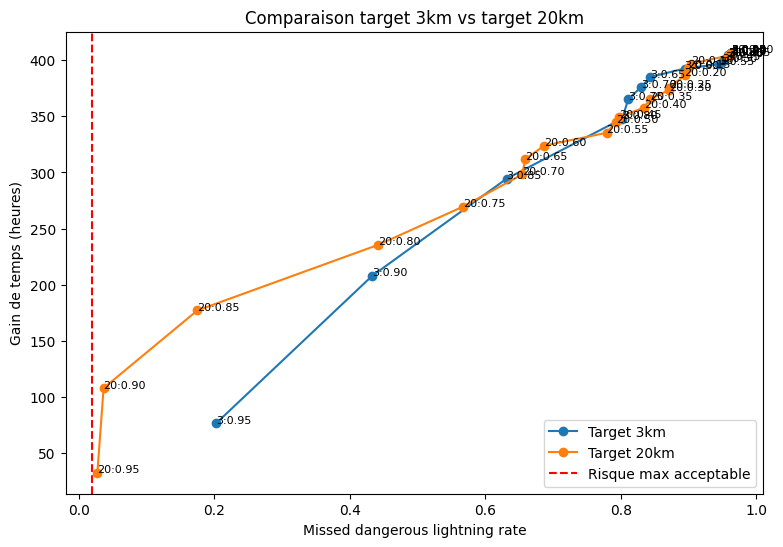

=== Meilleur 3km sous contrainte ===
Aucun seuil valide

=== Meilleur 20km sous contrainte ===
Aucun seuil valide


In [35]:
ACCEPTABLE_RISK = 0.02

plt.figure(figsize=(9, 6))

plt.plot(results_3["missed_rate"], results_3["gain_hours"], marker="o", label="Target 3km")
plt.plot(results_20["missed_rate"], results_20["gain_hours"], marker="o", label="Target 20km")

for _, row in results_3.iterrows():
    plt.text(row["missed_rate"], row["gain_hours"], f'3:{row["theta"]:.2f}', fontsize=8)

for _, row in results_20.iterrows():
    plt.text(row["missed_rate"], row["gain_hours"], f'20:{row["theta"]:.2f}', fontsize=8)

plt.axvline(ACCEPTABLE_RISK, color="red", linestyle="--", label="Risque max acceptable")
plt.xlabel("Missed dangerous lightning rate")
plt.ylabel("Gain de temps (heures)")
plt.title("Comparaison target 3km vs target 20km")
plt.legend()
plt.show()

valid_3 = results_3[results_3["missed_rate"] < ACCEPTABLE_RISK].copy()
valid_20 = results_20[results_20["missed_rate"] < ACCEPTABLE_RISK].copy()

print("=== Meilleur 3km sous contrainte ===")
if len(valid_3):
    print(valid_3.sort_values("gain_hours", ascending=False).iloc[0])
else:
    print("Aucun seuil valide")

print("\n=== Meilleur 20km sous contrainte ===")
if len(valid_20):
    print(valid_20.sort_values("gain_hours", ascending=False).iloc[0])
else:
    print("Aucun seuil valide")

In [36]:
feat_imp_3 = pd.DataFrame({
    "feature": X_train_3.columns,
    "importance": clf_3.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp_20 = pd.DataFrame({
    "feature": X_train_20.columns,
    "importance": clf_20.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 20 modèle 3km")
print(feat_imp_3.head(20))

print("\nTop 20 modèle 20km")
print(feat_imp_20.head(20))

Top 20 modèle 3km
                     feature  importance
17                 dayofyear         901
24        since_last_0_3_min         818
18                   weekday         461
19                  hour_sin         461
15                      hour         433
98  azimuth_mean__mean_60min         419
20                  hour_cos         375
97    maxis_mean__mean_60min         342
95  amp_abs_mean__mean_60min         321
0                    airport         297
86           n_cg__sum_60min         296
96   amp_abs_max__mean_60min         277
91        n_20_30__sum_60min         274
89         n_3_10__sum_60min         266
42   azimuth_mean__mean_5min         232
88          n_0_3__sum_60min         204
84  azimuth_mean__mean_30min         204
70  azimuth_mean__mean_20min         169
30            n_cg__sum_5min         155
81  amp_abs_mean__mean_30min         134

Top 20 modèle 20km
                      feature  importance
25        since_last_3_10_min         371
26       since_la

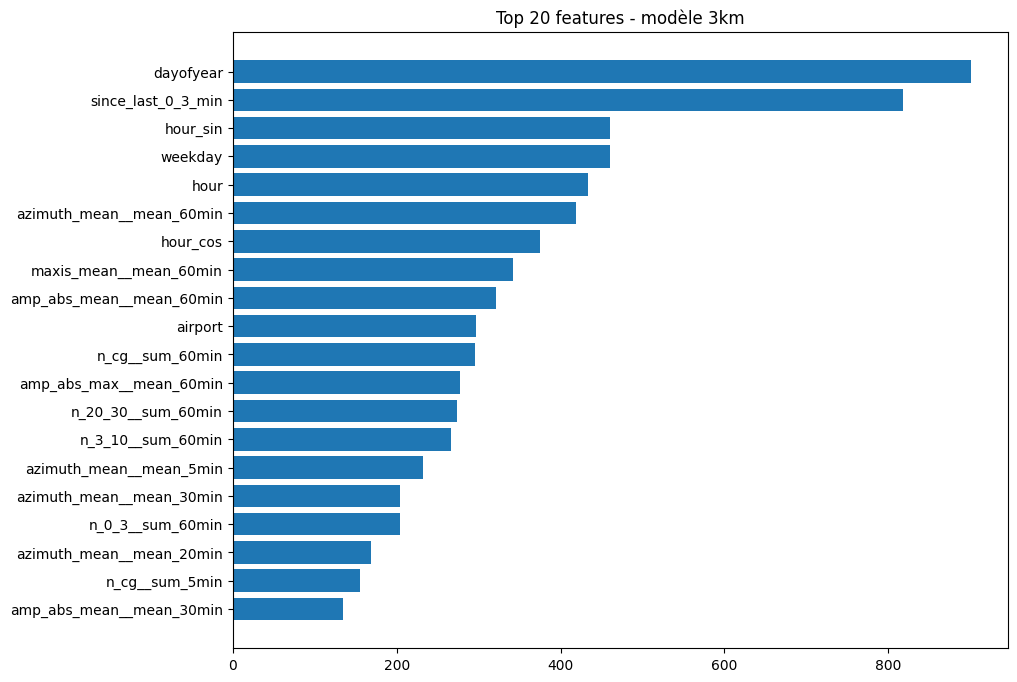

In [37]:
plt.figure(figsize=(10, 8))
topk = feat_imp_3.head(20).sort_values("importance")
plt.barh(topk["feature"], topk["importance"])
plt.title("Top 20 features - modèle 3km")
plt.show()

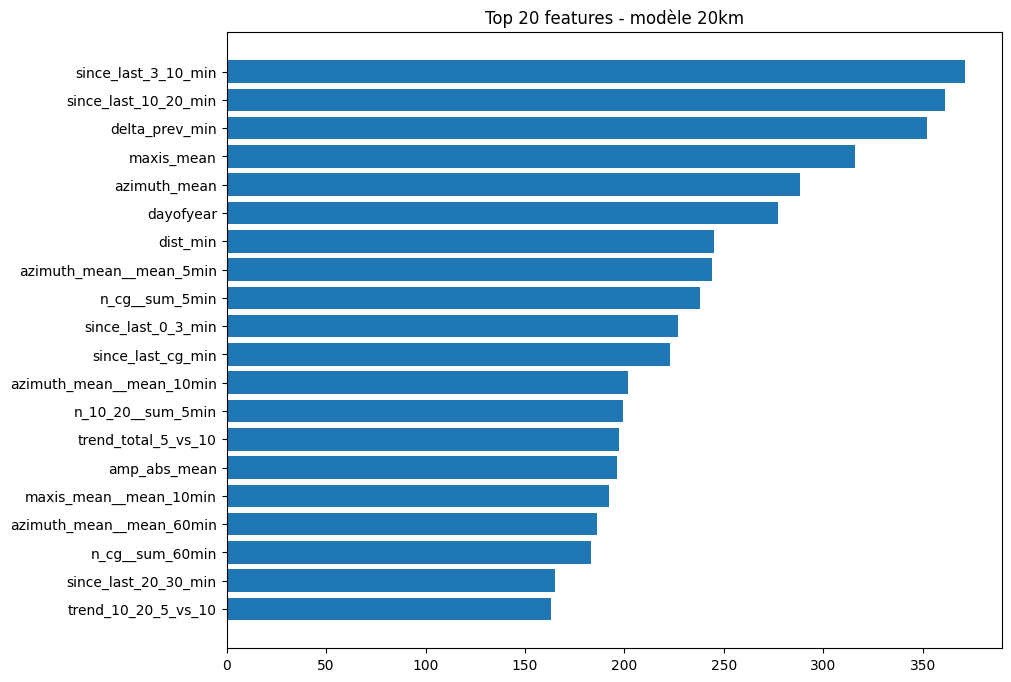

In [38]:
plt.figure(figsize=(10, 8))
topk = feat_imp_20.head(20).sort_values("importance")
plt.barh(topk["feature"], topk["importance"])
plt.title("Top 20 features - modèle 20km")
plt.show()

In [39]:
print(feat_imp_20.head(30))

                      feature  importance
25        since_last_3_10_min         371
26       since_last_10_20_min         361
23             delta_prev_min         352
13                 maxis_mean         316
14               azimuth_mean         288
17                  dayofyear         277
8                    dist_min         245
42    azimuth_mean__mean_5min         244
30             n_cg__sum_5min         238
24         since_last_0_3_min         227
28          since_last_cg_min         223
56   azimuth_mean__mean_10min         202
34          n_10_20__sum_5min         199
99        trend_total_5_vs_10         197
11               amp_abs_mean         196
55     maxis_mean__mean_10min         192
98   azimuth_mean__mean_60min         186
86            n_cg__sum_60min         183
27       since_last_20_30_min         165
101       trend_10_20_5_vs_10         163
41      maxis_mean__mean_5min         162
44            n_cg__sum_10min         160
9                   dist_mean     

/home/safsaf/miniconda3/lib/python3.13/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


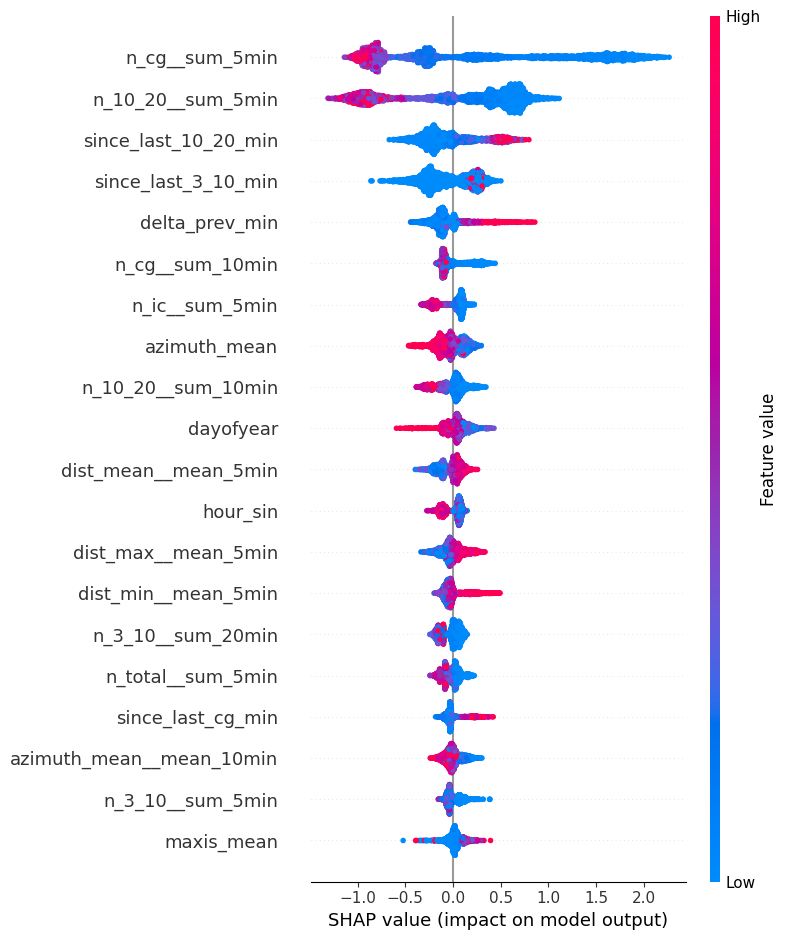

In [41]:
import shap

# échantillon pour aller plus vite
X_sample = X_val_20.sample(min(3000, len(X_val_20)), random_state=42)

explainer = shap.TreeExplainer(clf_20)
shap_values = explainer.shap_values(X_sample)

# selon versions shap/lightgbm, shap_values peut être une liste ou un array
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values
shap.summary_plot(shap_vals, X_sample, plot_type="dot")

In [43]:
val_airports = sorted(predictions_val_20_full["airport"].unique().tolist())
print("Aéroports en validation :", val_airports)

print("\nNb de lignes par aéroport dans predictions_val_20_full :")
print(predictions_val_20_full["airport"].value_counts())

print("\nNb de lignes labellisées par aéroport en validation :")
print(labeled.loc[labeled["date"] >= split_date, "airport"].value_counts())

KeyError: 'airport'

In [3]:
# ==========================================================
# A. Enrichissement de base
# ==========================================================
df = df.copy()

df["date"] = pd.to_datetime(df["date"], utc=True)

# Types
df["is_cg"] = (~df["icloud"]).astype("int8")
df["is_ic"] = df["icloud"].astype("int8")

# Distance rings
df["is_0_3"] = (df["dist"] < 3).astype("int8")
df["is_3_10"] = ((df["dist"] >= 3) & (df["dist"] < 10)).astype("int8")
df["is_10_20"] = ((df["dist"] >= 10) & (df["dist"] < 20)).astype("int8")
df["is_20_30"] = ((df["dist"] >= 20) & (df["dist"] < 30)).astype("int8")

# Amplitude
df["amp_abs"] = df["amplitude"].abs()

# Seuil "fort" basé sur le quantile 90 des CG
cg_abs_q90 = df.loc[df["is_cg"] == 1, "amp_abs"].quantile(0.90)
df["is_strong_cg"] = ((df["is_cg"] == 1) & (df["amp_abs"] >= cg_abs_q90)).astype("int8")

# Temps
df["hour"] = df["date"].dt.hour
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear
df["weekday"] = df["date"].dt.weekday

# Saisons
def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    elif m in [3, 4, 5]:
        return "spring"
    elif m in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

df["season"] = df["month"].apply(month_to_season)
df["is_summer"] = (df["season"] == "summer").astype("int8")
df["is_peak_hour"] = df["hour"].between(12, 18).astype("int8")

# Encodage cyclique
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Azimuth en sin/cos
az_rad = np.deg2rad(df["azimuth"])
df["azimuth_sin"] = np.sin(az_rad)
df["azimuth_cos"] = np.cos(az_rad)

# Secteurs angulaires (8 bins)
az_bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
az_labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
df["az_sector"] = pd.cut(
    df["azimuth"].mod(360),
    bins=az_bins,
    labels=az_labels,
    include_lowest=True,
    right=False
)

print("q90 CG amplitude abs =", cg_abs_q90)
print(df.head())

q90 CG amplitude abs = 50.26
   lightning_id  lightning_airport_id                      date     lon  \
0             1                     1 2016-01-02 14:53:36+00:00  9.0559   
1             2                     2 2016-01-02 14:53:36+00:00  9.0236   
2             3                     3 2016-01-02 21:22:53+00:00  8.8585   
3             4                     4 2016-01-02 21:22:53+00:00  8.8517   
4             5                     5 2016-01-02 21:24:46+00:00  8.8728   

       lat  amplitude  maxis  icloud       dist    azimuth  ...  season  \
0  42.0826      -9.90    0.3   False  27.360653  57.852343  ...  winter   
1  42.0953      -3.33    0.2    True  26.383167  52.117828  ...  winter   
2  42.0456     -18.68    0.4    True  14.313391  24.500543  ...  winter   
3  42.0517      -7.51    0.2   False  14.794117  20.854458  ...  winter   
4  42.0494      -6.01    0.2   False  15.124224  29.058471  ...  winter   

   is_summer is_peak_hour  hour_sin  hour_cos  month_sin  month_cos  

In [4]:
# ==========================================================
# B. Agrégation par (airport, date) — version plus rapide
# ==========================================================
df = df.copy()

# Pré-calculs pour éviter les lambda lents
df["cg_amp_abs"] = np.where(df["is_cg"] == 1, df["amp_abs"], np.nan)

base = (
    df.groupby(["airport", "date"], as_index=False)
      .agg(
          n_total=("lightning_id", "size"),
          n_cg=("is_cg", "sum"),
          n_ic=("is_ic", "sum"),
          n_strong_cg=("is_strong_cg", "sum"),

          n_0_3=("is_0_3", "sum"),
          n_3_10=("is_3_10", "sum"),
          n_10_20=("is_10_20", "sum"),
          n_20_30=("is_20_30", "sum"),

          dist_min=("dist", "min"),
          dist_mean=("dist", "mean"),
          dist_max=("dist", "max"),

          amp_abs_mean=("amp_abs", "mean"),
          amp_abs_max=("amp_abs", "max"),
          amp_abs_sum=("amp_abs", "sum"),

          cg_amp_abs_mean=("cg_amp_abs", "mean"),
          cg_amp_abs_max=("cg_amp_abs", "max"),

          maxis_mean=("maxis", "mean"),
          azimuth_mean=("azimuth", "mean"),
          azimuth_sin_mean=("azimuth_sin", "mean"),
          azimuth_cos_mean=("azimuth_cos", "mean"),

          hour=("hour", "first"),
          month=("month", "first"),
          dayofyear=("dayofyear", "first"),
          weekday=("weekday", "first"),
          season=("season", "first"),
          is_summer=("is_summer", "first"),
          is_peak_hour=("is_peak_hour", "first"),
          hour_sin=("hour_sin", "first"),
          hour_cos=("hour_cos", "first"),
          month_sin=("month_sin", "first"),
          month_cos=("month_cos", "first"),
      )
      .sort_values(["airport", "date"])
      .reset_index(drop=True)
)

# Remplissages pour les groupes sans CG
base["cg_amp_abs_mean"] = base["cg_amp_abs_mean"].fillna(0.0)
base["cg_amp_abs_max"] = base["cg_amp_abs_max"].fillna(0.0)

# proportions utiles
base["cg_ratio_now"] = base["n_cg"] / (base["n_total"] + 1e-6)
base["strong_cg_ratio_now"] = base["n_strong_cg"] / (base["n_cg"] + 1e-6)

print(base.shape)
print(base.head())

(568380, 35)
   airport                      date  n_total  n_cg  n_ic  n_strong_cg  n_0_3  \
0  Ajaccio 2016-01-02 14:53:36+00:00        2     1     1            0      0   
1  Ajaccio 2016-01-02 21:22:53+00:00        2     1     1            0      0   
2  Ajaccio 2016-01-02 21:24:46+00:00        1     1     0            0      0   
3  Ajaccio 2016-01-02 21:25:59+00:00        1     1     0            0      0   
4  Ajaccio 2016-01-02 21:27:04+00:00        1     1     0            0      0   

   n_3_10  n_10_20  n_20_30  ...  weekday  season  is_summer  is_peak_hour  \
0       0        0        2  ...        5  winter          0             1   
1       0        2        0  ...        5  winter          0             0   
2       0        1        0  ...        5  winter          0             0   
3       0        1        0  ...        5  winter          0             0   
4       0        1        0  ...        5  winter          0             0   

   hour_sin  hour_cos  month_si

In [5]:
# ==========================================================
# C. Comptages par secteurs angulaires
# ==========================================================
sector_counts = (
    df.groupby(["airport", "date", "az_sector"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

# renommer proprement
sector_cols = [c for c in sector_counts.columns if c not in ["airport", "date"]]
sector_counts = sector_counts.rename(columns={c: f"sector_{c}_count" for c in sector_cols})

base = base.merge(sector_counts, on=["airport", "date"], how="left")

for c in base.columns:
    if c.startswith("sector_") and c.endswith("_count"):
        base[c] = base[c].fillna(0)

print(base.filter(regex="^sector_|^airport$|^date$").head())

/tmp/ipykernel_104731/721502446.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["airport", "date", "az_sector"])


   airport                      date  sector_N_count  sector_NE_count  \
0  Ajaccio 2016-01-02 14:53:36+00:00               0                2   
1  Ajaccio 2016-01-02 21:22:53+00:00               2                0   
2  Ajaccio 2016-01-02 21:24:46+00:00               1                0   
3  Ajaccio 2016-01-02 21:25:59+00:00               1                0   
4  Ajaccio 2016-01-02 21:27:04+00:00               1                0   

   sector_E_count  sector_SE_count  sector_S_count  sector_SW_count  \
0               0                0               0                0   
1               0                0               0                0   
2               0                0               0                0   
3               0                0               0                0   
4               0                0               0                0   

   sector_W_count  sector_NW_count  
0               0                0  
1               0                0  
2               0      

In [6]:
# ==========================================================
# D. Temps depuis dernier événement
# ==========================================================
parts = []

for airport, g in base.groupby("airport"):
    g = g.sort_values("date").copy()

    g["delta_prev_min"] = g["date"].diff().dt.total_seconds().div(60).fillna(9999)

    def since_last(col_name, new_name):
        last_date = g["date"].where(g[col_name] > 0).ffill().shift()
        g[new_name] = (g["date"] - last_date).dt.total_seconds().div(60).fillna(9999)

    since_last("n_0_3", "since_last_0_3_min")
    since_last("n_3_10", "since_last_3_10_min")
    since_last("n_10_20", "since_last_10_20_min")
    since_last("n_20_30", "since_last_20_30_min")
    since_last("n_cg", "since_last_cg_min")
    since_last("n_strong_cg", "since_last_strong_cg_min")

    parts.append(g)

base_time = pd.concat(parts, ignore_index=True)

print(base_time.shape)
print(base_time.head())

(568380, 50)
   airport                      date  n_total  n_cg  n_ic  n_strong_cg  n_0_3  \
0  Ajaccio 2016-01-02 14:53:36+00:00        2     1     1            0      0   
1  Ajaccio 2016-01-02 21:22:53+00:00        2     1     1            0      0   
2  Ajaccio 2016-01-02 21:24:46+00:00        1     1     0            0      0   
3  Ajaccio 2016-01-02 21:25:59+00:00        1     1     0            0      0   
4  Ajaccio 2016-01-02 21:27:04+00:00        1     1     0            0      0   

   n_3_10  n_10_20  n_20_30  ...  sector_SW_count  sector_W_count  \
0       0        0        2  ...                0               0   
1       0        2        0  ...                0               0   
2       0        1        0  ...                0               0   
3       0        1        0  ...                0               0   
4       0        1        0  ...                0               0   

   sector_NW_count  delta_prev_min  since_last_0_3_min  since_last_3_10_min  \
0     

In [7]:
# ==========================================================
# E. Rolling windows
# ==========================================================
windows = ["5min", "10min", "20min", "30min", "60min"]

count_cols = [
    "n_total", "n_cg", "n_ic", "n_strong_cg",
    "n_0_3", "n_3_10", "n_10_20", "n_20_30"
]

mean_cols = [
    "dist_min", "dist_mean", "dist_max",
    "amp_abs_mean", "amp_abs_max", "amp_abs_sum",
    "cg_amp_abs_mean", "cg_amp_abs_max",
    "maxis_mean", "azimuth_sin_mean", "azimuth_cos_mean",
    "cg_ratio_now", "strong_cg_ratio_now"
]

sector_count_cols = [c for c in base_time.columns if c.startswith("sector_") and c.endswith("_count")]
count_cols_all = count_cols + sector_count_cols

parts = []

for airport, g in base_time.groupby("airport"):
    g = g.sort_values("date").copy().set_index("date")
    out = g.copy()

    for w in windows:
        roll_sum = g[count_cols_all].rolling(w, closed="both").sum()
        roll_sum.columns = [f"{c}__sum_{w}" for c in roll_sum.columns]

        roll_mean = g[mean_cols].rolling(w, closed="both").mean()
        roll_mean.columns = [f"{c}__mean_{w}" for c in roll_mean.columns]

        out = pd.concat([out, roll_sum, roll_mean], axis=1)

    out = out.reset_index()
    parts.append(out)

features_all = pd.concat(parts, ignore_index=True)

print(features_all.shape)
print(features_all.head())

(568380, 195)
                       date  airport  n_total  n_cg  n_ic  n_strong_cg  n_0_3  \
0 2016-01-02 14:53:36+00:00  Ajaccio        2     1     1            0      0   
1 2016-01-02 21:22:53+00:00  Ajaccio        2     1     1            0      0   
2 2016-01-02 21:24:46+00:00  Ajaccio        1     1     0            0      0   
3 2016-01-02 21:25:59+00:00  Ajaccio        1     1     0            0      0   
4 2016-01-02 21:27:04+00:00  Ajaccio        1     1     0            0      0   

   n_3_10  n_10_20  n_20_30  ...  amp_abs_mean__mean_60min  \
0       0        0        2  ...                   6.61500   
1       0        2        0  ...                  13.09500   
2       0        1        0  ...                   9.55250   
3       0        1        0  ...                  14.35500   
4       0        1        0  ...                  13.67875   

   amp_abs_max__mean_60min  amp_abs_sum__mean_60min  \
0                 9.900000                  13.2300   
1               

In [8]:
# ==========================================================
# F. Features dérivées : migration, tendance, sévérité
# ==========================================================
eps = 1e-6

# tendances d'activité
features_all["trend_total_5_vs_10"] = features_all["n_total__sum_5min"] / (features_all["n_total__sum_10min"] + eps)
features_all["trend_0_3_5_vs_10"] = features_all["n_0_3__sum_5min"] / (features_all["n_0_3__sum_10min"] + eps)
features_all["trend_10_20_5_vs_10"] = features_all["n_10_20__sum_5min"] / (features_all["n_10_20__sum_10min"] + eps)
features_all["trend_20_30_5_vs_10"] = features_all["n_20_30__sum_5min"] / (features_all["n_20_30__sum_10min"] + eps)
features_all["trend_cg_5_vs_10"] = features_all["n_cg__sum_5min"] / (features_all["n_cg__sum_10min"] + eps)

# proche vs loin
features_all["far_vs_near_5min"] = (features_all["n_20_30__sum_5min"] + 1) / (features_all["n_0_3__sum_5min"] + features_all["n_3_10__sum_5min"] + 1)
features_all["far_vs_near_10min"] = (features_all["n_20_30__sum_10min"] + 1) / (features_all["n_0_3__sum_10min"] + features_all["n_3_10__sum_10min"] + 1)
features_all["far_vs_mid_10min"] = (features_all["n_20_30__sum_10min"] + 1) / (features_all["n_10_20__sum_10min"] + 1)
features_all["mid_vs_near_10min"] = (features_all["n_10_20__sum_10min"] + 1) / (features_all["n_0_3__sum_10min"] + features_all["n_3_10__sum_10min"] + 1)

# migration spatiale simple
features_all["dist_range_now"] = features_all["dist_max"] - features_all["dist_min"]
features_all["dist_range_10min"] = features_all["dist_max__mean_10min"] - features_all["dist_min__mean_10min"]
features_all["dist_drift_5_10"] = features_all["dist_mean__mean_5min"] - features_all["dist_mean__mean_10min"]
features_all["near_drop_signal"] = (
    (features_all["n_0_3__sum_10min"] + features_all["n_3_10__sum_10min"] + 1)
    / (features_all["n_10_20__sum_10min"] + features_all["n_20_30__sum_10min"] + 1)
)

# sévérité heuristique instantanée
# 40% amplitude, 40% CG, 20% proximité
features_all["severity_now"] = (
    0.4 * np.tanh(features_all["amp_abs_mean"] / 20.0) +
    0.4 * features_all["cg_ratio_now"] +
    0.2 * (1 - np.clip(features_all["dist_mean"] / 30.0, 0, 1))
)

# versions roulantes de la sévérité
for w in ["5min", "10min", "30min"]:
    features_all[f"severity_{w}"] = (
        0.4 * np.tanh(features_all[f"amp_abs_mean__mean_{w}"] / 20.0) +
        0.4 * features_all[f"cg_ratio_now__mean_{w}"] +
        0.2 * (1 - np.clip(features_all[f"dist_mean__mean_{w}"] / 30.0, 0, 1))
    )

# intensité récente forte
features_all["strong_cg_ratio_10min"] = features_all["n_strong_cg__sum_10min"] / (features_all["n_cg__sum_10min"] + eps)
features_all["strong_cg_ratio_30min"] = features_all["n_strong_cg__sum_30min"] / (features_all["n_cg__sum_30min"] + eps)

print(features_all.shape)
print(features_all[[
    "airport", "date", "severity_now", "severity_5min", "severity_10min",
    "far_vs_near_10min", "mid_vs_near_10min", "dist_drift_5_10"
]].head())

(568380, 214)
   airport                      date  severity_now  severity_5min  \
0  Ajaccio 2016-01-02 14:53:36+00:00      0.348532       0.348532   
1  Ajaccio 2016-01-02 21:22:53+00:00      0.532918       0.532918   
2  Ajaccio 2016-01-02 21:24:46+00:00      0.615879       0.578809   
3  Ajaccio 2016-01-02 21:25:59+00:00      0.829324       0.678956   
4  Ajaccio 2016-01-02 21:27:04+00:00      0.707502       0.686620   

   severity_10min  far_vs_near_10min  mid_vs_near_10min  dist_drift_5_10  
0        0.348532                3.0                1.0              0.0  
1        0.532918                1.0                3.0              0.0  
2        0.578809                1.0                4.0              0.0  
3        0.678956                1.0                5.0              0.0  
4        0.686620                1.0                6.0              0.0  


In [9]:
# ==========================================================
# G. Cycle de vie d'alerte (sur lignes labellisées)
# ==========================================================
labeled = df[df["airport_alert_id"].notna()].copy()
labeled = labeled.sort_values(["airport", "airport_alert_id", "date"]).copy()

life_parts = []

for (airport, alert_id), g in labeled.groupby(["airport", "airport_alert_id"]):
    g = g.sort_values("date").copy()

    g["elapsed_since_alert_start_min"] = (
        g["date"] - g["date"].iloc[0]
    ).dt.total_seconds().div(60)

    g["cum_lightnings"] = np.arange(1, len(g) + 1)
    g["cum_cg"] = g["is_cg"].cumsum()
    g["cum_ic"] = g["is_ic"].cumsum()
    g["cum_strong_cg"] = g["is_strong_cg"].cumsum()

    g["cum_avg_rate"] = g["cum_lightnings"] / (g["elapsed_since_alert_start_min"] + 1)
    g["cum_cg_rate"] = g["cum_cg"] / (g["elapsed_since_alert_start_min"] + 1)
    g["cum_strong_cg_rate"] = g["cum_strong_cg"] / (g["elapsed_since_alert_start_min"] + 1)

    # timestamp unique dans l'alerte
    g_ts = (
        g.groupby(["airport", "airport_alert_id", "date"], as_index=False)
         .agg(
             elapsed_since_alert_start_min=("elapsed_since_alert_start_min", "max"),
             cum_lightnings=("cum_lightnings", "max"),
             cum_cg=("cum_cg", "max"),
             cum_ic=("cum_ic", "max"),
             cum_strong_cg=("cum_strong_cg", "max"),
             cum_avg_rate=("cum_avg_rate", "max"),
             cum_cg_rate=("cum_cg_rate", "max"),
             cum_strong_cg_rate=("cum_strong_cg_rate", "max"),
         )
    )

    life_parts.append(g_ts)

alert_life_df = pd.concat(life_parts, ignore_index=True)

print(alert_life_df.shape)
print(alert_life_df.head())

(67051, 11)
   airport  airport_alert_id                      date  \
0  Ajaccio               1.0 2016-01-02 21:22:53+00:00   
1  Ajaccio               1.0 2016-01-02 21:24:46+00:00   
2  Ajaccio               1.0 2016-01-02 21:25:59+00:00   
3  Ajaccio               1.0 2016-01-02 21:27:04+00:00   
4  Ajaccio               1.0 2016-01-02 21:28:54+00:00   

   elapsed_since_alert_start_min  cum_lightnings  cum_cg  cum_ic  \
0                       0.000000               1       1       0   
1                       1.883333               2       2       0   
2                       3.100000               3       3       0   
3                       4.183333               4       4       0   
4                       6.016667               5       5       0   

   cum_strong_cg  cum_avg_rate  cum_cg_rate  cum_strong_cg_rate  
0              0      1.000000     1.000000                 0.0  
1              0      0.693642     0.693642                 0.0  
2              0      0.731707  

In [10]:
# ==========================================================
# H. Targets 3km / 20km
# ==========================================================
target_rows = []

for (airport, alert_id), g in labeled.groupby(["airport", "airport_alert_id"]):
    g = g.sort_values("date").copy()

    times = g[["date"]].drop_duplicates().sort_values("date").copy()
    t = times["date"].to_numpy()

    dangerous_times_3 = np.array(sorted(g.loc[g["dist"] < 3, "date"].unique()))
    dangerous_times_20 = np.array(sorted(g.loc[g["dist"] < 20, "date"].unique()))

    idx3 = np.searchsorted(dangerous_times_3, t, side="right")
    idx20 = np.searchsorted(dangerous_times_20, t, side="right")

    times["safe_to_end_now_3km"] = (idx3 == len(dangerous_times_3)).astype("int8")
    times["safe_to_end_now_20km"] = (idx20 == len(dangerous_times_20)).astype("int8")
    times["airport"] = airport
    times["airport_alert_id"] = alert_id

    target_rows.append(times)

target_df = pd.concat(target_rows, ignore_index=True)

print(target_df.shape)
print(target_df.head())
print(target_df[["safe_to_end_now_3km", "safe_to_end_now_20km"]].mean())

(67051, 5)
                       date  safe_to_end_now_3km  safe_to_end_now_20km  \
0 2016-01-02 21:22:53+00:00                    1                     0   
1 2016-01-02 21:24:46+00:00                    1                     0   
2 2016-01-02 21:25:59+00:00                    1                     0   
3 2016-01-02 21:27:04+00:00                    1                     0   
4 2016-01-02 21:28:54+00:00                    1                     1   

   airport  airport_alert_id  
0  Ajaccio               1.0  
1  Ajaccio               1.0  
2  Ajaccio               1.0  
3  Ajaccio               1.0  
4  Ajaccio               1.0  
safe_to_end_now_3km     0.513370
safe_to_end_now_20km    0.047785
dtype: float64


In [11]:
# ==========================================================
# I. Stats locales par aéroport
# ==========================================================
# stats d'alertes
alerts_stats = (
    labeled.groupby(["airport", "airport_alert_id"], as_index=False)
           .agg(
               alert_start=("date", "min"),
               alert_end=("date", "max"),
               n_lightnings_alert=("lightning_id", "count"),
               n_cg_alert=("is_cg", "sum"),
               n_ic_alert=("is_ic", "sum"),
               mean_amp_alert=("amp_abs", "mean"),
           )
)

alerts_stats["alert_duration_min"] = (
    alerts_stats["alert_end"] - alerts_stats["alert_start"]
).dt.total_seconds().div(60)

airport_static = (
    alerts_stats.groupby("airport", as_index=False)
               .agg(
                   airport_alert_duration_mean=("alert_duration_min", "mean"),
                   airport_alert_duration_median=("alert_duration_min", "median"),
                   airport_alert_n_lightnings_mean=("n_lightnings_alert", "mean"),
                   airport_alert_n_lightnings_median=("n_lightnings_alert", "median"),
                   airport_alert_cg_mean=("n_cg_alert", "mean"),
                   airport_alert_ic_mean=("n_ic_alert", "mean"),
                   airport_alert_amp_mean=("mean_amp_alert", "mean"),
               )
)

# stats saisonnières
labeled["season"] = labeled["month"].apply(month_to_season)
airport_season_static = (
    labeled.groupby(["airport", "season"], as_index=False)
           .agg(
               airport_season_mean_dist=("dist", "mean"),
               airport_season_cg_ratio=("is_cg", "mean"),
               airport_season_amp_mean=("amp_abs", "mean"),
           )
)

# pivot saison
airport_season_pivot = airport_season_static.pivot(index="airport", columns="season")
airport_season_pivot.columns = [
    f"{a}_{b}" for a, b in airport_season_pivot.columns.to_flat_index()
]
airport_season_pivot = airport_season_pivot.reset_index()

airport_static = airport_static.merge(airport_season_pivot, on="airport", how="left")

print(airport_static.shape)
print(airport_static.head())

(5, 20)
    airport  airport_alert_duration_mean  airport_alert_duration_median  \
0   Ajaccio                    29.602654                      11.333333   
1    Bastia                    33.894804                      13.608333   
2  Biarritz                    26.344856                       8.708333   
3    Nantes                    27.815359                      11.466667   
4      Pise                    34.449315                      14.850000   

   airport_alert_n_lightnings_mean  airport_alert_n_lightnings_median  \
0                        19.902866                                3.0   
1                        25.414706                                4.0   
2                        17.399441                                3.0   
3                        19.572549                                3.0   
4                        25.025946                                3.0   

   airport_alert_cg_mean  airport_alert_ic_mean  airport_alert_amp_mean  \
0              19.902866   

In [12]:
# ==========================================================
# J. Fusion finale
# ==========================================================
model_df = (
    target_df
    .merge(features_all, on=["airport", "date"], how="left")
    .merge(alert_life_df, on=["airport", "airport_alert_id", "date"], how="left")
    .merge(airport_static, on="airport", how="left")
)

# catégorielles
model_df["airport"] = model_df["airport"].astype("category")
model_df["season"] = model_df["season"].astype("category")

print("Shape model_df :", model_df.shape)
print(model_df.head())

Shape model_df : (67051, 244)
                       date  safe_to_end_now_3km  safe_to_end_now_20km  \
0 2016-01-02 21:22:53+00:00                    1                     0   
1 2016-01-02 21:24:46+00:00                    1                     0   
2 2016-01-02 21:25:59+00:00                    1                     0   
3 2016-01-02 21:27:04+00:00                    1                     0   
4 2016-01-02 21:28:54+00:00                    1                     1   

   airport  airport_alert_id  n_total  n_cg  n_ic  n_strong_cg  n_0_3  ...  \
0  Ajaccio               1.0        2     1     1            0      0  ...   
1  Ajaccio               1.0        1     1     0            0      0  ...   
2  Ajaccio               1.0        1     1     0            0      0  ...   
3  Ajaccio               1.0        1     1     0            0      0  ...   
4  Ajaccio               1.0        2     1     1            0      0  ...   

   airport_season_mean_dist_summer  airport_season_mean_

In [13]:
# ==========================================================
# K. Split temporel
# ==========================================================
split_train_end = pd.Timestamp("2024-01-01", tz="UTC")
split_val_end = pd.Timestamp("2025-01-01", tz="UTC")

train_mask = model_df["date"] < split_train_end
val_mask = (model_df["date"] >= split_train_end) & (model_df["date"] < split_val_end)

drop_cols_common = [
    "airport_alert_id",
    "date",
    "safe_to_end_now_3km",
    "safe_to_end_now_20km"
]

feature_cols = [c for c in model_df.columns if c not in drop_cols_common]

# version 20km
X_train_20 = model_df.loc[train_mask, feature_cols].copy()
y_train_20 = model_df.loc[train_mask, "safe_to_end_now_20km"].copy()

X_val_20 = model_df.loc[val_mask, feature_cols].copy()
y_val_20 = model_df.loc[val_mask, "safe_to_end_now_20km"].copy()

# version 3km
X_train_3 = model_df.loc[train_mask, feature_cols].copy()
y_train_3 = model_df.loc[train_mask, "safe_to_end_now_3km"].copy()

X_val_3 = model_df.loc[val_mask, feature_cols].copy()
y_val_3 = model_df.loc[val_mask, "safe_to_end_now_3km"].copy()

print("20km train:", X_train_20.shape, "positive rate =", y_train_20.mean())
print("20km val  :", X_val_20.shape, "positive rate =", y_val_20.mean())
print("3km train :", X_train_3.shape, "positive rate =", y_train_3.mean())
print("3km val   :", X_val_3.shape, "positive rate =", y_val_3.mean())

20km train: (58545, 240) positive rate = 0.048697583055769066
20km val  : (3965, 240) positive rate = 0.04842370744010088
3km train : (58545, 240) positive rate = 0.5090101631223845
3km val   : (3965, 240) positive rate = 0.5543505674653215


In [14]:
# ==========================================================
# L. Entraînement
# ==========================================================
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

cat_cols = ["airport", "season"]

params = dict(
    objective="binary",
    n_estimators=600,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    class_weight="balanced",
    random_state=42,
    verbose=-1
)

clf_20 = LGBMClassifier(**params)
clf_3 = LGBMClassifier(**params)

clf_20.fit(X_train_20, y_train_20, categorical_feature=cat_cols)
clf_3.fit(X_train_3, y_train_3, categorical_feature=cat_cols)

val_proba_20 = clf_20.predict_proba(X_val_20)[:, 1]
val_proba_3 = clf_3.predict_proba(X_val_3)[:, 1]

print("=== Modèle 20km ===")
print("ROC-AUC      :", roc_auc_score(y_val_20, val_proba_20))
print("Avg Precision:", average_precision_score(y_val_20, val_proba_20))
print("Brier score  :", brier_score_loss(y_val_20, val_proba_20))

print("\n=== Modèle 3km ===")
print("ROC-AUC      :", roc_auc_score(y_val_3, val_proba_3))
print("Avg Precision:", average_precision_score(y_val_3, val_proba_3))
print("Brier score  :", brier_score_loss(y_val_3, val_proba_3))

=== Modèle 20km ===
ROC-AUC      : 0.8204926451099921
Avg Precision: 0.1783056908848618
Brier score  : 0.09958404357234829

=== Modèle 3km ===
ROC-AUC      : 0.8211897629835839
Avg Precision: 0.8268566389370191
Brier score  : 0.1729276875149404


In [17]:
predictions_val_20 = model_df.loc[val_mask, ["airport", "airport_alert_id", "date"]].copy()
predictions_val_20["prediction_date"] = predictions_val_20["date"]
predictions_val_20["predicted_date_end_alert"] = predictions_val_20["date"]
predictions_val_20["confidence"] = val_proba_20
predictions_val_20 = predictions_val_20[
    ["airport", "airport_alert_id", "prediction_date", "predicted_date_end_alert", "confidence"]
].copy()

print(predictions_val_20.head())

       airport  airport_alert_id           prediction_date  \
10895  Ajaccio             619.0 2024-02-20 13:29:34+00:00   
10896  Ajaccio             619.0 2024-02-20 13:30:48+00:00   
10897  Ajaccio             619.0 2024-02-20 13:34:02+00:00   
10898  Ajaccio             619.0 2024-02-20 13:35:59+00:00   
10899  Ajaccio             619.0 2024-02-20 13:40:47+00:00   

       predicted_date_end_alert  confidence  
10895 2024-02-20 13:29:34+00:00    0.860589  
10896 2024-02-20 13:30:48+00:00    0.672915  
10897 2024-02-20 13:34:02+00:00    0.559737  
10898 2024-02-20 13:35:59+00:00    0.634493  
10899 2024-02-20 13:40:47+00:00    0.573554  


In [18]:
def evaluate_predictions(predictions_df, labeled_df, split_date, max_gap_minutes=30, min_dist=3):
    val_labeled_raw = labeled_df[
        (labeled_df["date"] >= split_date) &
        (labeled_df["date"] < pd.Timestamp("2025-01-01", tz="UTC"))
    ].copy()

    alerts_val = val_labeled_raw.groupby(["airport", "airport_alert_id"])
    tot_lightnings_val = len(val_labeled_raw[val_labeled_raw["dist"] < min_dist])

    thetas = [i / 20 for i in range(20)]
    rows = []

    for theta in thetas:
        pred_over_theta = predictions_df[predictions_df["confidence"] >= theta].copy()

        pred_over_theta_min = (
            pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
            .min()
        )

        gain = 0
        missed_lights = 0
        n_alerts_predicted = 0

        for (airport, alert_id), end_alert_pred in pred_over_theta_min.items():
            if (airport, alert_id) not in alerts_val.groups:
                continue

            lightnings = alerts_val.get_group((airport, alert_id))
            n_alerts_predicted += 1

            end_alert_baseline = (
                pd.to_datetime(lightnings["date"], utc=True).max()
                + pd.Timedelta(minutes=max_gap_minutes)
            )

            gain += (end_alert_baseline - end_alert_pred).total_seconds()

            missed_lights += (
                pd.to_datetime(lightnings.loc[lightnings["dist"] < min_dist, "date"], utc=True)
                > end_alert_pred
            ).sum()

        rows.append({
            "theta": theta,
            "gain_hours": gain / 3600,
            "missed_rate": missed_lights / max(tot_lightnings_val, 1),
            "missed_count": missed_lights,
            "n_alerts_predicted": n_alerts_predicted
        })

    return pd.DataFrame(rows)

In [21]:
def evaluate_predictions(predictions_df, labeled_df, split_date, max_gap_minutes=30, min_dist=3):
    val_labeled_raw = labeled_df[
        (labeled_df["date"] >= split_date) &
        (labeled_df["date"] < pd.Timestamp("2025-01-01", tz="UTC"))
    ].copy()

    alerts_val = val_labeled_raw.groupby(["airport", "airport_alert_id"])
    tot_lightnings_val = len(val_labeled_raw[val_labeled_raw["dist"] < min_dist])

    thetas = [i / 20 for i in range(20)]
    rows = []

    for theta in thetas:
        pred_over_theta = predictions_df[predictions_df["confidence"] >= theta].copy()

        pred_over_theta_min = (
            pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
            .min()
        )

        gain_seconds = 0.0
        missed_lights = 0
        n_alerts_predicted = 0
        n_invalid_groups = 0

        for (airport, alert_id), end_alert_pred in pred_over_theta_min.items():
            if (airport, alert_id) not in alerts_val.groups:
                continue

            lightnings = alerts_val.get_group((airport, alert_id))

            end_alert_pred = pd.to_datetime(end_alert_pred, utc=True, errors="coerce")
            end_alert_baseline = pd.to_datetime(lightnings["date"], utc=True, errors="coerce").max()

            if pd.isna(end_alert_pred) or pd.isna(end_alert_baseline):
                n_invalid_groups += 1
                continue

            end_alert_baseline = end_alert_baseline + pd.Timedelta(minutes=max_gap_minutes)

            gain_seconds += (end_alert_baseline - end_alert_pred).total_seconds()
            n_alerts_predicted += 1

            missed_lights += (
                pd.to_datetime(lightnings.loc[lightnings["dist"] < min_dist, "date"], utc=True, errors="coerce")
                > end_alert_pred
            ).sum()

        rows.append({
            "theta": theta,
            "gain_hours": gain_seconds / 3600,
            "missed_rate": missed_lights / max(tot_lightnings_val, 1),
            "missed_count": missed_lights,
            "n_alerts_predicted": n_alerts_predicted,
            "n_invalid_groups": n_invalid_groups
        })

    return pd.DataFrame(rows)

In [22]:
results_20 = evaluate_predictions(predictions_val_20, labeled, split_train_end, max_gap_minutes=30, min_dist=3)
print(results_20)

/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning

    theta  gain_hours  missed_rate  missed_count  n_alerts_predicted  \
0    0.00  212.628889     0.973684           111                 192   
1    0.05  212.342222     0.973684           111                 192   
2    0.10  208.548333     0.956140           109                 192   
3    0.15  206.187222     0.956140           109                 190   
4    0.20  202.278889     0.947368           108                 188   
5    0.25  200.387222     0.903509           103                 187   
6    0.30  200.332500     0.903509           103                 187   
7    0.35  194.296667     0.850877            97                 180   
8    0.40  190.093056     0.807018            92                 177   
9    0.45  187.967222     0.807018            92                 176   
10   0.50  180.709167     0.719298            82                 171   
11   0.55  175.090278     0.482456            55                 168   
12   0.60  167.383889     0.482456            55                

/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning

In [23]:
predictions_val_3 = model_df.loc[val_mask, ["airport", "airport_alert_id", "date"]].copy()
predictions_val_3["prediction_date"] = predictions_val_3["date"]
predictions_val_3["predicted_date_end_alert"] = predictions_val_3["date"]
predictions_val_3["confidence"] = val_proba_3
predictions_val_3 = predictions_val_3[
    ["airport", "airport_alert_id", "prediction_date", "predicted_date_end_alert", "confidence"]
].copy()

print(predictions_val_3.head())

       airport  airport_alert_id           prediction_date  \
10895  Ajaccio             619.0 2024-02-20 13:29:34+00:00   
10896  Ajaccio             619.0 2024-02-20 13:30:48+00:00   
10897  Ajaccio             619.0 2024-02-20 13:34:02+00:00   
10898  Ajaccio             619.0 2024-02-20 13:35:59+00:00   
10899  Ajaccio             619.0 2024-02-20 13:40:47+00:00   

       predicted_date_end_alert  confidence  
10895 2024-02-20 13:29:34+00:00    0.979949  
10896 2024-02-20 13:30:48+00:00    0.977574  
10897 2024-02-20 13:34:02+00:00    0.982787  
10898 2024-02-20 13:35:59+00:00    0.951666  
10899 2024-02-20 13:40:47+00:00    0.945546  


In [24]:
results_3 = evaluate_predictions(predictions_val_3, labeled, split_train_end, max_gap_minutes=30, min_dist=3)
print(results_3)

/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning

    theta  gain_hours  missed_rate  missed_count  n_alerts_predicted  \
0    0.00  212.628889     0.973684           111                 192   
1    0.05  212.628889     0.973684           111                 192   
2    0.10  212.628889     0.973684           111                 192   
3    0.15  212.628889     0.973684           111                 192   
4    0.20  212.628889     0.973684           111                 192   
5    0.25  212.628889     0.973684           111                 192   
6    0.30  212.470278     0.973684           111                 192   
7    0.35  212.201389     0.973684           111                 192   
8    0.40  212.145278     0.973684           111                 192   
9    0.45  211.446389     0.964912           110                 192   
10   0.50  209.632500     0.921053           105                 192   
11   0.55  209.034444     0.885965           101                 192   
12   0.60  207.827778     0.885965           101                

/tmp/ipykernel_104731/4130878775.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pred_over_theta.groupby(["airport", "airport_alert_id"])["predicted_date_end_alert"]
